Лабораторная 8

In [1]:
import torch
import numpy as np
import cv2
from PIL import Image
import matplotlib.pyplot as plt
from diffusers import StableDiffusionPipeline, DDIMScheduler
from insightface.app import FaceAnalysis

SEED = 52
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

torch.backends.cudnn.benchmark = True

device = torch.device("cuda" )

GENDER = "man"
FACE_IMAGE_PATH = "my_face.jpg"

Извлечение эмбеддинга лица с помощью InsightFace

Applied providers: ['CUDAExecutionProvider', 'CPUExecutionProvider'], with options: {'CUDAExecutionProvider': {'device_id': '0', 'has_user_compute_stream': '0', 'cudnn_conv1d_pad_to_nc1d': '0', 'user_compute_stream': '0', 'gpu_external_alloc': '0', 'gpu_mem_limit': '18446744073709551615', 'enable_cuda_graph': '0', 'gpu_external_free': '0', 'gpu_external_empty_cache': '0', 'arena_extend_strategy': 'kNextPowerOfTwo', 'cudnn_conv_algo_search': 'EXHAUSTIVE', 'do_copy_in_default_stream': '1', 'cudnn_conv_use_max_workspace': '1', 'tunable_op_enable': '0', 'tunable_op_tuning_enable': '0', 'tunable_op_max_tuning_duration_ms': '0', 'enable_skip_layer_norm_strict_mode': '0', 'prefer_nhwc': '0', 'use_ep_level_unified_stream': '0', 'use_tf32': '1', 'sdpa_kernel': '0', 'fuse_conv_bias': '0'}, 'CPUExecutionProvider': {}}
find model: C:\Users\mrsiz/.insightface\models\buffalo_l\1k3d68.onnx landmark_3d_68 ['None', 3, 192, 192] 0.0 1.0
Applied providers: ['CUDAExecutionProvider', 'CPUExecutionProvider'

C:\Users\mrsiz\PycharmProjects\ml-26-labs\.venv\Lib\site-packages\insightface\utils\face_align.py:23: FutureWarning: `estimate` is deprecated since version 0.26 and will be removed in version 2.2. Please use `SimilarityTransform.from_estimate` class constructor instead.
  tform.estimate(lmk, dst)


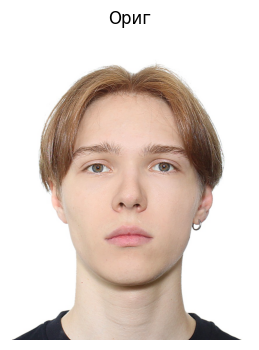

In [2]:
face_app = FaceAnalysis(
    name="buffalo_l",
    providers=["CUDAExecutionProvider", "CPUExecutionProvider"]
)
face_app.prepare(ctx_id=0, det_size=(640, 640))

ref_image = cv2.imread(FACE_IMAGE_PATH)

faces = face_app.get(ref_image)
face_embedding = faces[0].normed_embedding
face_embed = torch.from_numpy(face_embedding).reshape(1, 1, -1).to(device, dtype=torch.float16)  # (1, 1, 512)
neg_embed = torch.zeros_like(face_embed)   # (1, 1, 512)
faceid_embeds = torch.cat([neg_embed, face_embed], dim=0)  # (2, 1, 512)

plt.figure(figsize=(4, 4))
plt.imshow(cv2.cvtColor(ref_image, cv2.COLOR_BGR2RGB))
plt.title("Ориг")
plt.axis("off")
plt.show()

Загрузка Stable Diffusion + IP-Adapter-FaceID

In [3]:
pipe = StableDiffusionPipeline.from_pretrained(
    "SG161222/Realistic_Vision_V4.0_noVAE",
    torch_dtype=torch.float16,
    safety_checker=None
)

pipe.scheduler = DDIMScheduler.from_config(pipe.scheduler.config)

pipe.load_ip_adapter(
    "h94/IP-Adapter-FaceID",
    subfolder="",
    weight_name="ip-adapter-faceid_sd15.bin",
    image_encoder_folder=None
)

pipe.load_lora_weights(
    "h94/IP-Adapter-FaceID",
    weight_name="ip-adapter-faceid_sd15_lora.safetensors",
    adapter_name="faceid_lora"
)
pipe.fuse_lora(lora_scale=0.7)

pipe.set_ip_adapter_scale(0.7)

pipe = pipe.to(device)

try:
    pipe.enable_xformers_memory_efficient_attention()
except Exception:
    print("bruh")

Loading pipeline components...:   0%|          | 0/5 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

image_encoder is not loaded since `image_encoder_folder=None` passed. You will not be able to use `ip_adapter_image` when calling the pipeline with IP-Adapter.Use `ip_adapter_image_embeds` to pass pre-generated image embedding instead.
No LoRA keys associated to CLIPTextModel found with the prefix='text_encoder'. This is safe to ignore if LoRA state dict didn't originally have any CLIPTextModel related params. You can also try specifying `prefix=None` to resolve the warning. Otherwise, open an issue if you think it's unexpected: https://github.com/huggingface/diffusers/issues/new
C:\Users\mrsiz\PycharmProjects\ml-26-labs\.venv\Lib\site-packages\peft\tuners\tuners_utils.py:302: UserWarning: Already found a `peft_config` attribute in the model. This will lead to having multiple adapters in the model. Make sure to know what you are doing!
  warnings.warn(
No LoRA keys associated to CLIPTextModel found with the prefix='text_encoder'. This is safe to ignore if LoRA state dict didn't origina

bruh


Вспомогательная функция генерации

In [4]:
def generate_face_image(
    prompt: str,
    face_embeds: torch.Tensor,
    num_steps: int = 30,
    guidance_scale: float = 7.0,
    seed: int = SEED,
    width: int = 512,
    height: int = 512
) -> Image.Image:
    generator = torch.Generator(device=device).manual_seed(seed)

    result = pipe(
        prompt=prompt,
        ip_adapter_image_embeds=[face_embeds],
        num_inference_steps=num_steps,
        guidance_scale=guidance_scale,
        generator=generator,
        width=width,
        height=height
    )
    return result.images[0]


def show_images(images: list, titles: list, cols: int = 3, figsize=(15, 10)):
    rows = (len(images) + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=figsize)
    axes = axes.flatten() if rows * cols > 1 else [axes]
    for i, (img, title) in enumerate(zip(images, titles)):
        axes[i].imshow(img)
        axes[i].set_title(title, fontsize=10)
        axes[i].axis("off")
    for j in range(len(images), len(axes)):
        axes[j].axis("off")
    plt.tight_layout()
    plt.show()

Одно качественное изображение (стиль: киберпанк)

  0%|          | 0/50 [00:00<?, ?it/s]

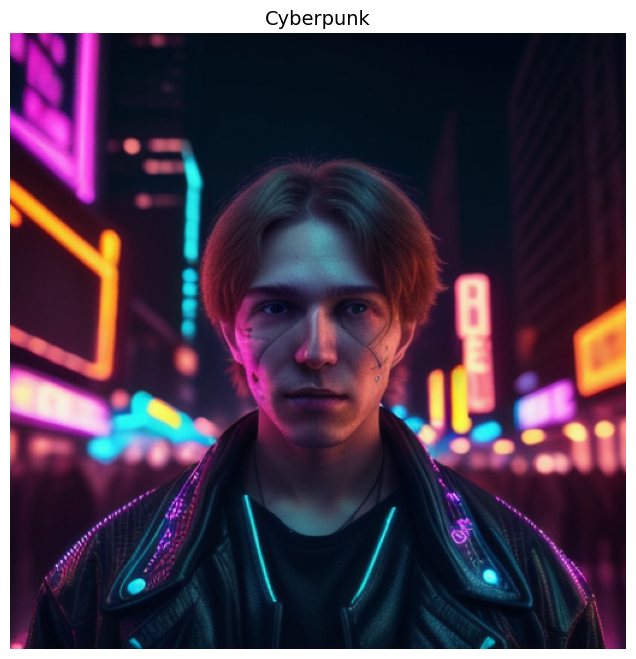

In [5]:
high_quality_prompt = (
    f"portrait photo of a {GENDER} in a cyberpunk neon city at night, "
    f"glowing lights, detailed face, ultra realistic, 8k, professional photography"
)

hq_image = generate_face_image(
    prompt=high_quality_prompt,
    face_embeds=faceid_embeds,
    num_steps=50,
    guidance_scale=7.5,
    seed=42
)

plt.figure(figsize=(8, 8))
plt.imshow(hq_image)
plt.title("Cyberpunk", fontsize=14)
plt.axis("off")
plt.show()

Ещё 5 изображений в разных стилях

Генерация [1/5]: Металл...


  0%|          | 0/30 [00:00<?, ?it/s]

Генерация [2/5]: Космос...


  0%|          | 0/30 [00:00<?, ?it/s]

Генерация [3/5]: Средневековье...


  0%|          | 0/30 [00:00<?, ?it/s]

Генерация [4/5]: Поп-арт...


  0%|          | 0/30 [00:00<?, ?it/s]

Генерация [5/5]: Под водой...


  0%|          | 0/30 [00:00<?, ?it/s]

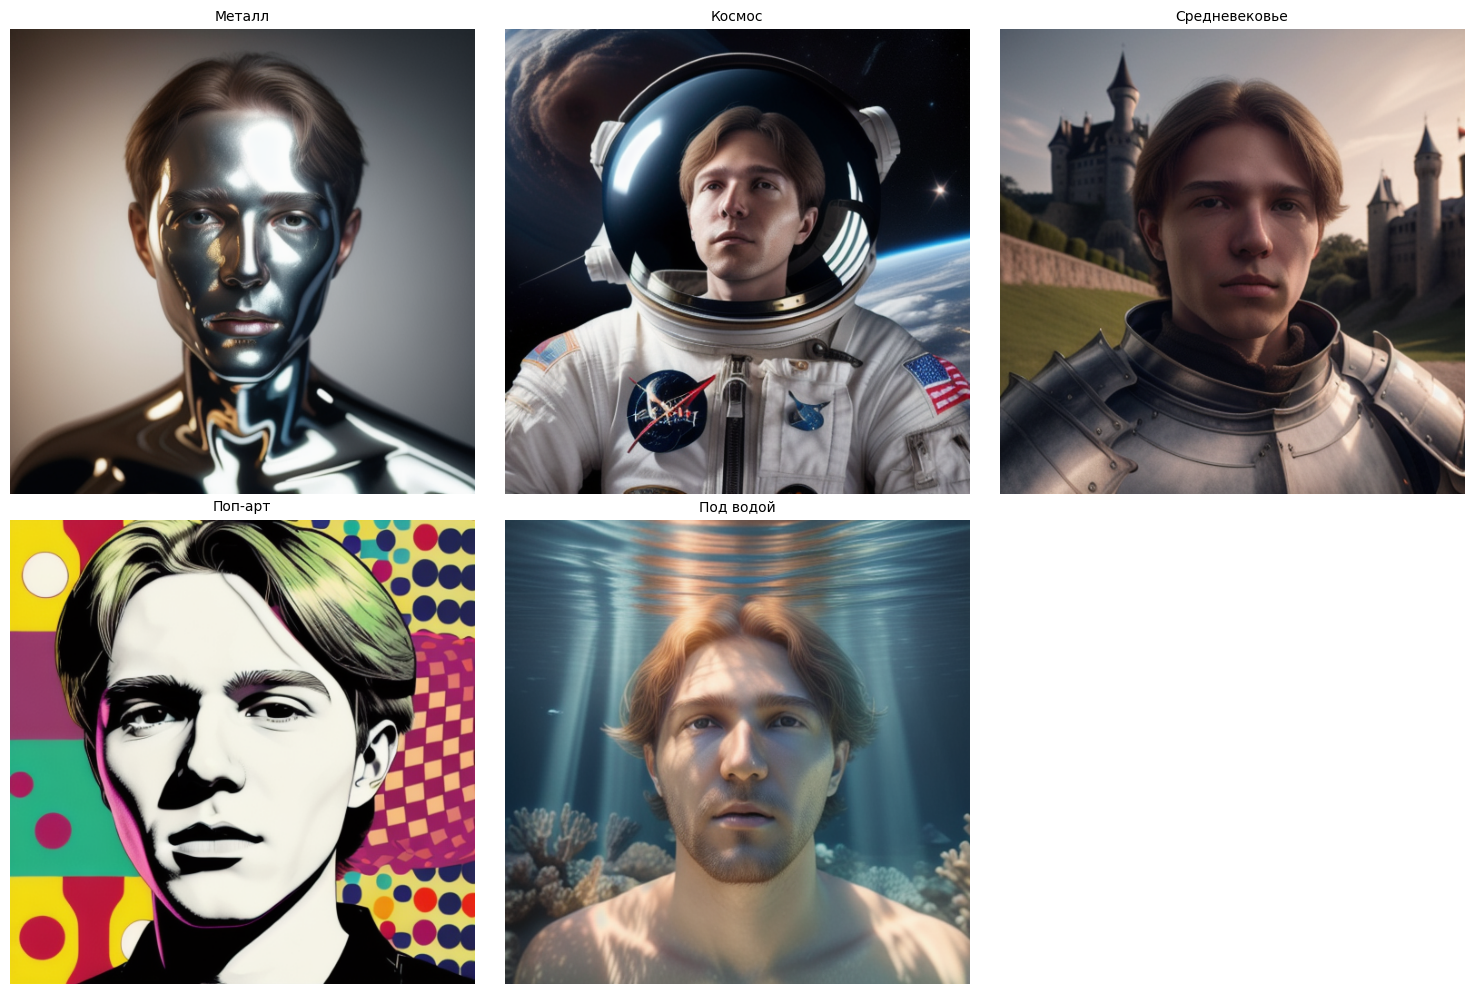

In [6]:
style_prompts = {
    "Металл": (
        f"portrait photo of a {GENDER} made of shiny metal, chrome skin, "
        f"metallic texture, studio lighting, ultra realistic, 8k"
    ),
    "Космос": (
        f"portrait photo of a {GENDER} astronaut floating in outer space, "
        f"earth in background, stars, space suit, ultra realistic, 8k"
    ),
    "Средневековье": (
        f"portrait photo of a {GENDER} medieval knight in shining armor, "
        f"castle background, dramatic lighting, ultra realistic, 8k"
    ),
    "Поп-арт": (
        f"portrait of a {GENDER} in pop art style, bold colors, "
        f"comic book halftone dots, Andy Warhol inspired, vibrant"
    ),
    "Под водой": (
        f"portrait photo of a {GENDER} swimming underwater, "
        f"coral reef, tropical fish, blue water, sunlight rays, ultra realistic, 8k"
    ),
}

style_images = []
style_titles = []

for i, (style_name, prompt) in enumerate(style_prompts.items()):
    print(f"Генерация [{i+1}/5]: {style_name}...")
    img = generate_face_image(
        prompt=prompt,
        face_embeds=faceid_embeds,
        num_steps=30,
        guidance_scale=7.0,
        seed=SEED + i
    )
    style_images.append(img)
    style_titles.append(style_name)
    img.save(f"result_style_{i+1}_{style_name}.png")

show_images(style_images, style_titles, cols=3, figsize=(15, 10))

forest / city / beach

Генерация [1/3]: man in a forest...


  0%|          | 0/30 [00:00<?, ?it/s]

Генерация [2/3]: man in a city...


  0%|          | 0/30 [00:00<?, ?it/s]

Генерация [3/3]: man in a beach...


  0%|          | 0/30 [00:00<?, ?it/s]

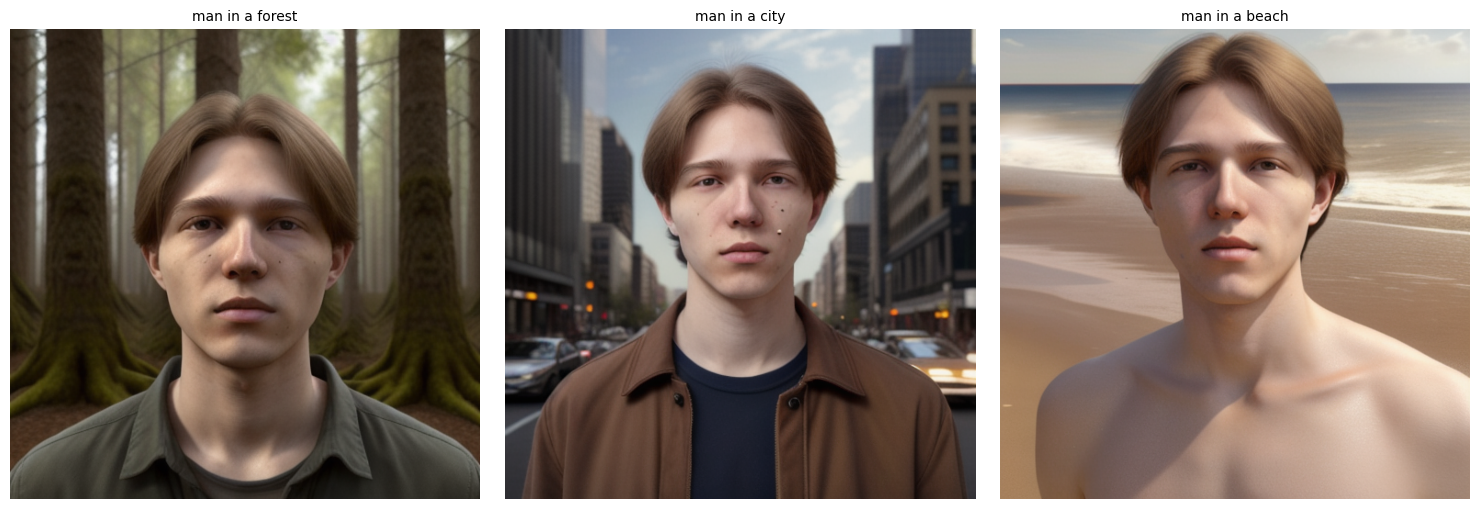

In [7]:
location_prompts = {
    f"{GENDER} in a forest": f"{GENDER} in a forest, high quality, realism",
    f"{GENDER} in a city":   f"{GENDER} in a city, high quality, realism",
    f"{GENDER} in a beach":  f"{GENDER} in a beach, high quality, realism",
}

location_images = []
location_titles = []

for i, (title, prompt) in enumerate(location_prompts.items()):
    print(f"Генерация [{i+1}/3]: {title}...")
    img = generate_face_image(
        prompt=prompt,
        face_embeds=faceid_embeds,
        num_steps=30,
        guidance_scale=7.0,
        seed=SEED + 100 + i
    )
    location_images.append(img)
    location_titles.append(title)

show_images(location_images, location_titles, cols=3, figsize=(15, 5))